# Computational Project: Non-elementary 1st-order ODEs
Daniel Li, Yixuan Li, Eric Chen

Problems 2, 6, 7, 13, 16

Problem 2: $y' = y/t + t, [1, 5], y_0 = 2$ \
Problem 6: $y' = 3t - y/t, [1, 4], y_0 = 2$ \
Problem 7: $y' = t - 2ty, [0, 2], y_0 = 1$ \
Problem 13: $y' = \sin(e^t), [0, 4], y_0 = 0$ \
Problem 16: $y' = \cos(ty), [0, 6], y_0 = 1$

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from collections.abc import Callable
from scipy.integrate import solve_ivp

f64 = np.float64
f64arr = np.typing.NDArray[f64]

In [3]:
def method_euler(yp: Callable[[f64, f64], f64], t: f64arr, y0: f64) -> f64arr:
    y = np.zeros(t.size, dtype=f64)
    y[0] = y0

    for i in range(1, y.size):
        y[i] = y[i-1] + (t[i] - t[i-1]) * yp(t[i-1], y[i-1])
    return y

def method_heun(yp: Callable[[f64, f64], f64], t: f64arr, y0: f64) -> f64arr:
    y = np.zeros(t.size, dtype=f64)
    y[0] = y0

    for i in range(1, y.size):
        pred = y[i-1] + (t[i] - t[i-1]) * yp(t[i-1], y[i-1])
        y[i] = y[i-1] + (t[i] - t[i-1])/2 * (yp(t[i-1], y[i-1]) + yp(t[i], pred))
    return y

def method_rk45(yp: Callable[[f64, f64], f64], t: f64arr, y0: f64) -> f64arr:
    sol = solve_ivp(yp, [t[0], t[-1]], [y0], method='RK45')
    return sol.t, sol.y[0]

def plot_methods(yp: Callable[[f64, f64], f64], t0: f64, L: f64, y0: f64) -> f64arr:
    t_h1 = t0 + np.arange(0, L + 0.001, 0.1)
    t_h2 = t0 + np.arange(0, L + 0.001, 0.01)

    plt.plot(t_h1, method_euler(yp, t_h1, y0), label="Euler h=0.1")
    plt.plot(t_h2, method_euler(yp, t_h2, y0), label="Euler h=0.01")
    plt.plot(t_h1, method_heun(yp, t_h1, y0), label="Heun h=0.1")
    plt.plot(t_h2, method_heun(yp, t_h2, y0), label="Heun h=0.01")
    plt.plot(*method_rk45(yp, [t0, t0 + L], y0), label="RK45")

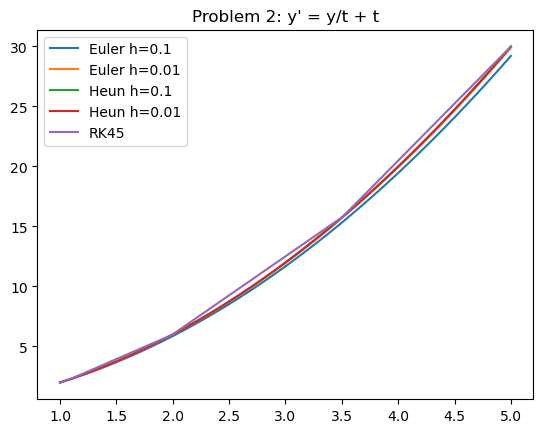

In [4]:
plot_methods(
    yp=lambda t, y: y/t + t,
    t0=1,
    L=4,
    y0=2
)
plt.legend()
plt.title("Problem 2: y' = y/t + t")
plt.show()

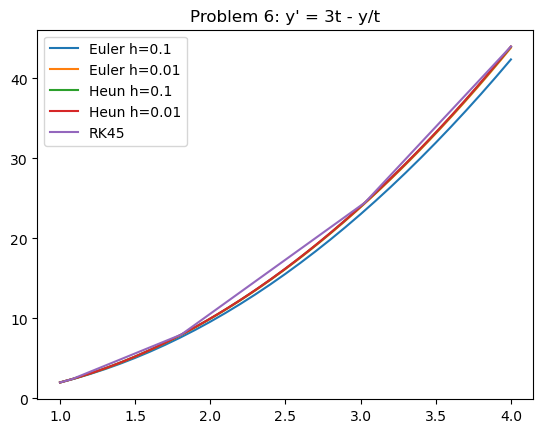

In [5]:
plot_methods(
    yp=lambda t, y: 3*t + y/t,
    t0=1,
    L=3,
    y0=2
)
plt.legend()
plt.title("Problem 6: y' = 3t - y/t")
plt.show()

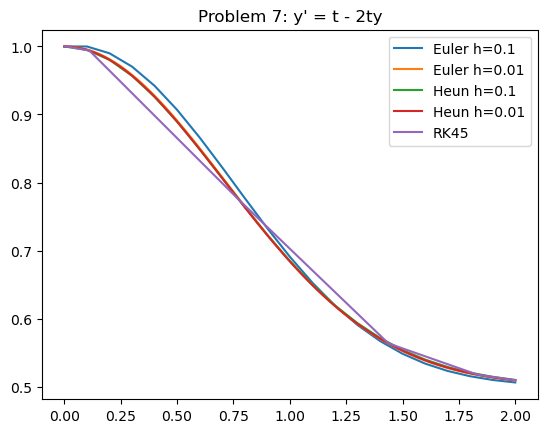

In [6]:
plot_methods(
    yp=lambda t, y: t - 2*t*y,
    t0=0,
    L=2,
    y0=1
)
plt.legend()
plt.title("Problem 7: y' = t - 2ty")
plt.show()

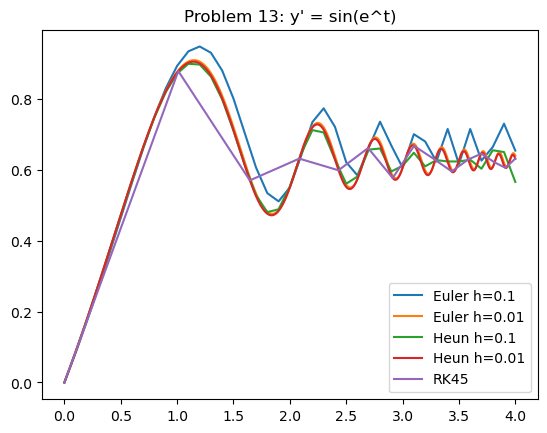

In [7]:
plot_methods(
    yp=lambda t, y: np.sin(np.exp(t)),
    t0=0,
    L=4,
    y0=0
)
plt.legend()
plt.title("Problem 13: y' = sin(e^t)")
plt.show()

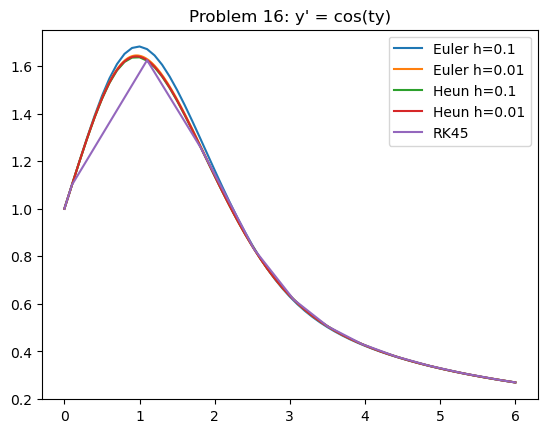

In [8]:
plot_methods(
    yp=lambda t, y: np.cos(t*y),
    t0=0,
    L=6,
    y0=1
)
plt.legend()
plt.title("Problem 16: y' = cos(ty)")
plt.show()